<a href="https://colab.research.google.com/github/Soham-47/pipelines/blob/main/DETR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import torch as th
import requests
from PIL import Image , ImageDraw , ImageFont
import torchvision.transforms as T

In [2]:
model=th.hub.load("facebookresearch/detr", "detr_resnet101" , pretrained=True)

Downloading: "https://github.com/facebookresearch/detr/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 142MB/s]


Downloading: "https://dl.fbaipublicfiles.com/detr/detr-r101-2c7b67e5.pth" to /root/.cache/torch/hub/checkpoints/detr-r101-2c7b67e5.pth


100%|██████████| 232M/232M [00:14<00:00, 17.0MB/s]


In [4]:
url=input()

https://images.unsplash.com/photo-1589828155685-83225f7d91f3?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D


In [5]:
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


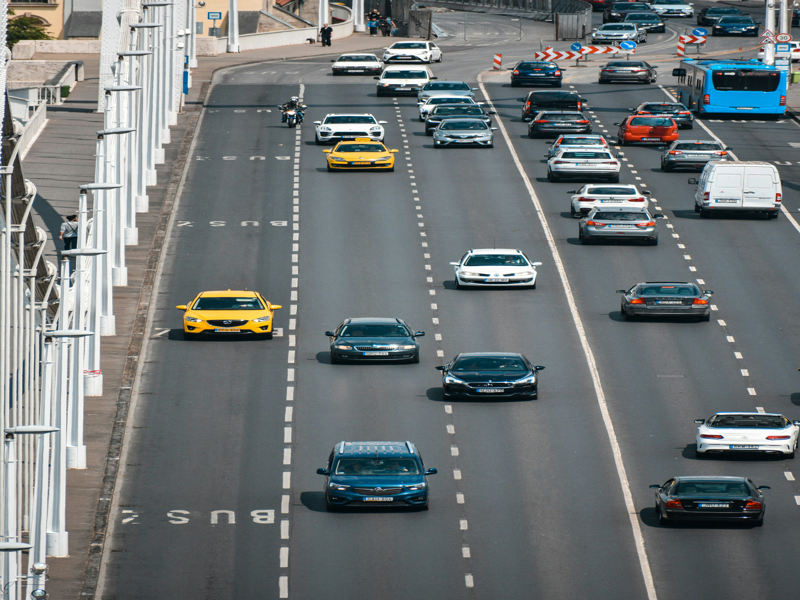

In [6]:
img= Image.open(requests.get(url , stream=True).raw).resize((800,600))
img

In [9]:
img_tens=transform(img).unsqueeze(0).shape

In [12]:
model.eval()

DETR(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, ou

In [15]:
with th.no_grad():
  img_tens = transform(img).unsqueeze(0)
  output=model(img_tens)

In [17]:
output["pred_boxes"].shape

torch.Size([1, 100, 4])

In [19]:
output["pred_logits"][0].argmax(dim=-1)

tensor([91,  3,  4,  3, 91, 91, 91,  3, 91, 91,  1,  3,  4,  1,  3, 91, 91, 91,
         3,  3,  1, 91,  1,  3, 91, 91, 91, 91, 91, 91,  1,  3,  3, 91, 91,  1,
        91, 91, 91, 91,  1,  3, 91,  3, 91, 91, 91, 91,  3, 91, 91,  3, 91,  3,
         1, 91,  3, 91,  1,  1, 91, 91, 91, 91, 91, 91, 91,  1, 91, 91,  8,  3,
        91,  8, 91,  1, 91, 91,  3,  3, 91, 91,  8,  3,  3, 91, 91, 91,  6,  3,
         1, 91, 91, 91, 91, 91,  3,  3,  3, 91])

In [37]:
im2 = img.copy()
drw = ImageDraw.Draw(im2)

for logits , box_coords in zip(output["pred_logits"][0], output["pred_boxes"][0]):
  cls=logits.argmax()
  if cls>=len(CLASSES):
    continue
  label=CLASSES[cls]

  img_w, img_h = img.size
  cx, cy, w, h = box_coords.tolist()

  x0 = (cx - w/2) * img_w
  y0 = (cy - h/2) * img_h
  x1 = (cx + w/2) * img_w
  y1 = (cy + h/2) * img_h

  drw.rectangle([x0,y0,x1,y1], outline="red", width=2)
  drw.text((x0, y0), label , fill="white")

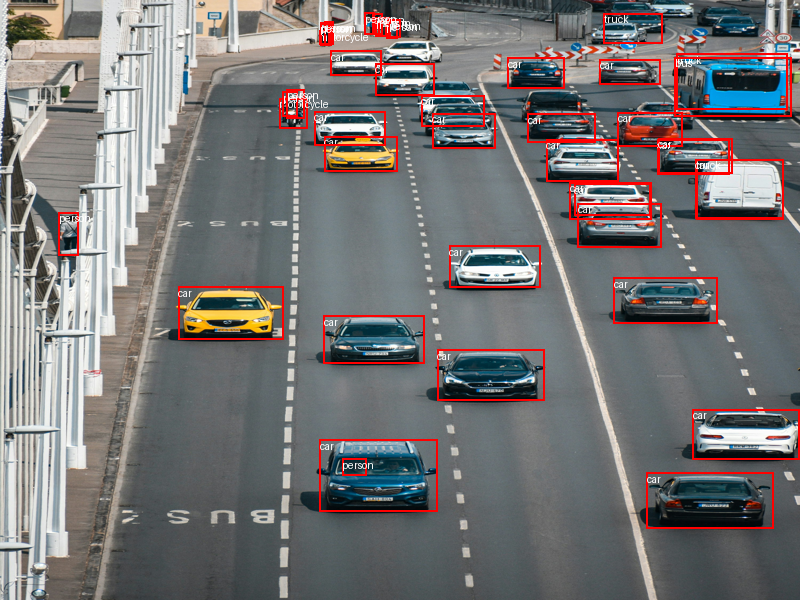

In [38]:
im2